# Moments

If the points represent mass:
- the zeroth moment is the total mass
- the first moment divided by the total mass is the center of mass

If the points represent probability density:
- the zeroth moment is the total probability (i.e. one)
- the first moment is the mean
- the second central moment is the variance
- the third standardized moment is the skewness

## Key Statistical Concepts

- The **mean** is the expected value of a feature
- The **variance** is a central moment that describes the spread around an expected value
- The **skewness** is a standardized moment that describes the degree to which the feature's distribution deviates from the normal distribution

## Common Transformations

### Centering (Mean Removal)
To centralize a feature, subtract the mean:

(-10.0, 10.0)

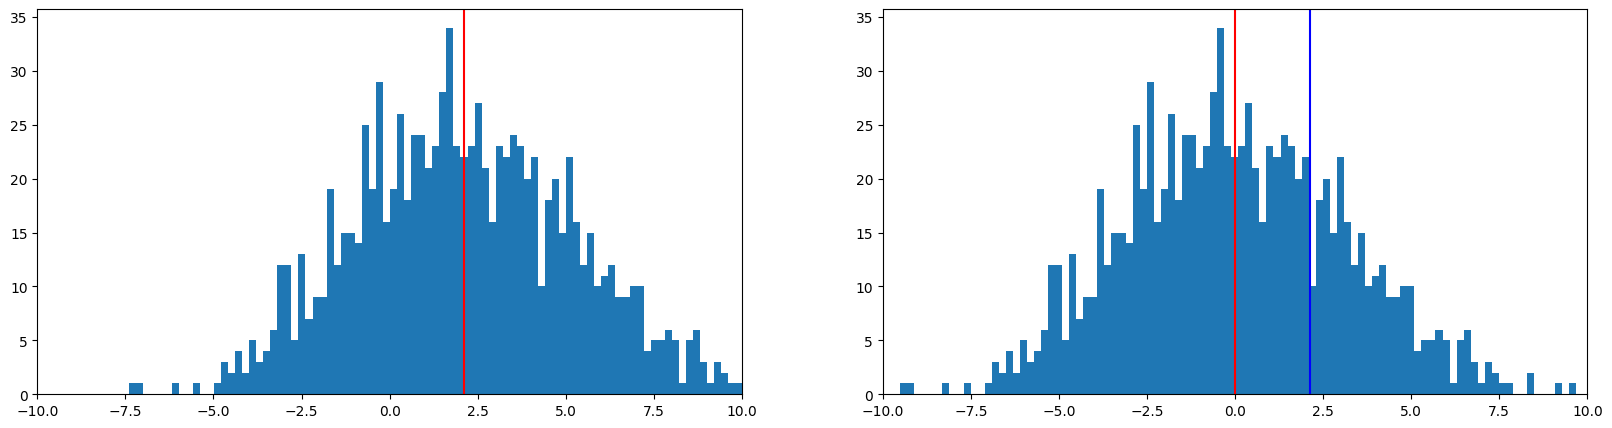

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def create_sample_normal(test_mean=2.3, test_std=3):
    xx = np.random.normal(test_mean,test_std,1000)
    return xx

xx = create_sample_normal()
xx_c = xx - xx.mean() # vectorized operation

fig, ax = plt.subplots(1,2, figsize=(20,5))
ax[0].hist(xx,bins=100);
ax[0].axvline(xx.mean(),c='red')
ax[0].set_xlim(-10,10)

ax[1].hist(xx_c,bins=100);
ax[1].axvline(xx_c.mean(),c='red')
ax[1].axvline(xx.mean(),c='blue')
ax[1].set_xlim(-10,10)

In [2]:
xx[:20]

array([ 4.72229113,  3.35568829, -0.76411647,  2.48461773, -0.51123472,
       -2.18577656, 10.46443731,  1.39871507,  2.98319281,  3.11317548,
        4.75671576, -2.98514377,  4.63543745,  6.6647188 ,  1.64796676,
       -0.63757998,  7.06993095,  4.72852081,  3.53961467,  1.07927003])

(-10.0, 10.0)

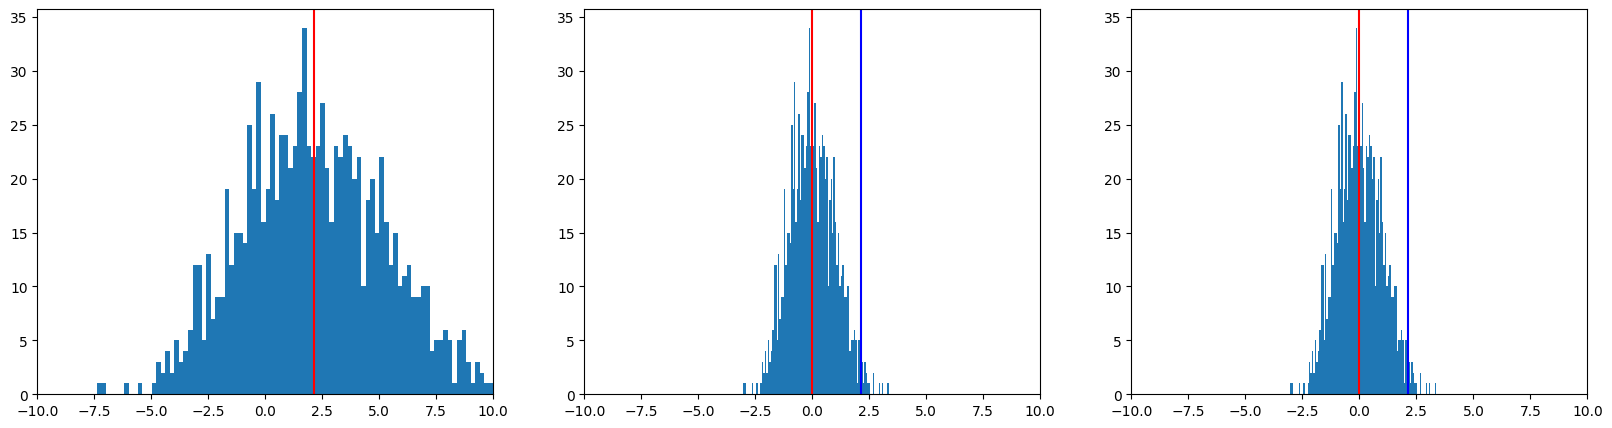

In [3]:
from sklearn.preprocessing import StandardScaler

xx_std = (xx - xx.mean()) / xx.std() # vectorized operations 

xx_std_sk = StandardScaler().fit_transform(xx.reshape(-1,1)) # vectorized operation

fig, ax = plt.subplots(1,3, figsize=(20,5))
ax[0].hist(xx,bins=100);
ax[0].axvline(xx.mean(),c='red')
ax[0].set_xlim(-10,10)

ax[1].hist(xx_std,bins=100);
ax[1].axvline(xx_std.mean(),c='red')
ax[1].axvline(xx.mean(),c='blue')
ax[1].set_xlim(-10,10)

ax[2].hist(xx_std_sk,bins=100);
ax[2].axvline(xx_std_sk.mean(),c='red')
ax[2].axvline(xx.mean(),c='blue')
ax[2].set_xlim(-10,10)

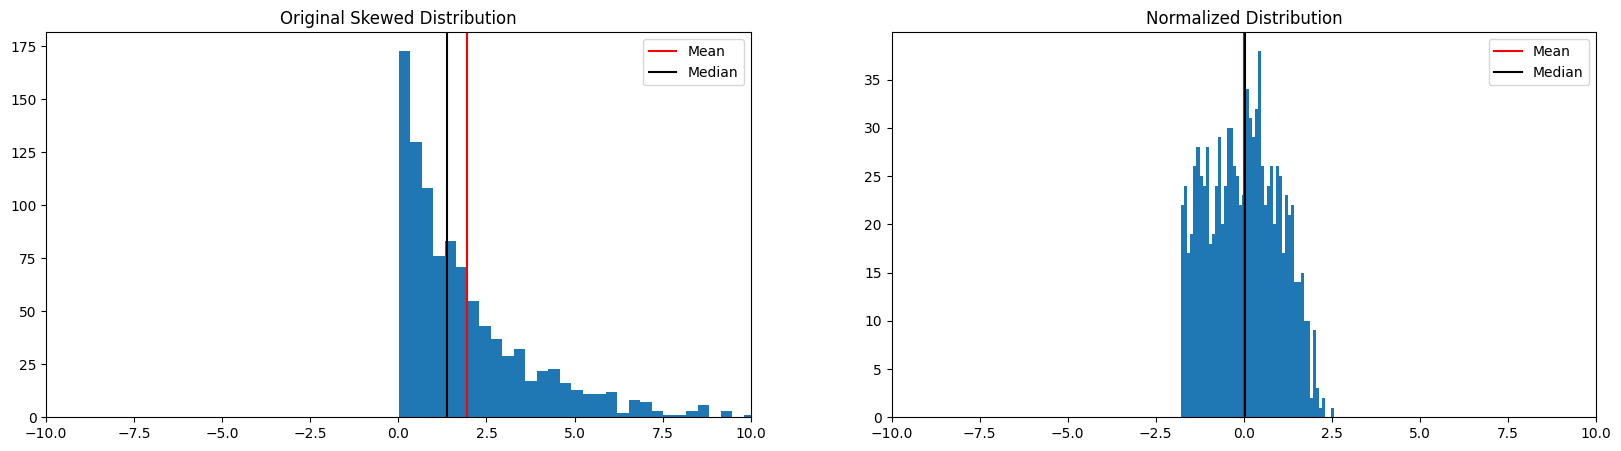

Skewness before: 1.865034222864843
Skewness after: [0.0689552]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

# Create a skewed distribution using exponential
np.random.seed(42)  # For reproducibility
xx_skewed = np.random.exponential(scale=2.0, size=1000) # skew-normal distribution

# Use PowerTransformer to normalize (this handles skewed distributions well)
pt = PowerTransformer(method='yeo-johnson')
xx_normalized = pt.fit_transform(xx_skewed.reshape(-1, 1))

# Plot the original and normalized distributions
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Original skewed distribution
ax[0].hist(xx_skewed, bins=50)
ax[0].axvline(xx_skewed.mean(), c='red', label='Mean')
ax[0].axvline(np.median(xx_skewed), c='black', label='Median')
ax[0].set_title('Original Skewed Distribution')
ax[0].set_xlim(-10,10)
ax[0].legend()

# Normalized distribution
ax[1].hist(xx_normalized, bins=50)
ax[1].axvline(xx_normalized.mean(), c='red', label='Mean')
ax[1].axvline(np.median(xx_normalized), c='black', label='Median')
ax[1].set_title('Normalized Distribution')
ax[1].set_xlim(-10,10)
ax[1].legend()

plt.show()

# Print skewness before and after
from scipy.stats import skew
print(f"Skewness before:", skew(xx_skewed.astype(float)))
print(f"Skewness after:", skew(xx_normalized.astype(float)))